In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
# read in all the words
words = open('../data/names.txt', 'r').read().splitlines()
words[:8]

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [3]:
len(words)

32033

In [4]:
#build the vocabulary of characters and mappings to/from integers
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
vocab_size = len(itos)
print(itos)
print (vocab_size)


{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}
27


In [5]:
# building the dataset
block_size = 3 # context length: how many characters do we take to predict the next one

def build_dataset(words):
    X, Y = [], []

    for w in words:
        context = [0] * block_size
        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            context = context[1:] + [ix] # crop and append
    X = torch.tensor(X)
    Y = torch.tensor(Y)
    print(X.shape, Y.shape)
    return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8 * len(words))
n2 = int(0.9 * len(words))

X_tr, Y_tr = build_dataset(words[:n1])      # 80%
X_dev, Y_dev = build_dataset(words[n1:n2])  # 10%
X_te, Y_te = build_dataset(words[n2:])      # 10%

torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])


In [6]:
# MLP revisited
n_embd = 10 # the dimensionality of the character embedding vectors
n_hidden = 200 # number of neurons in the hidden layer of the MLP

g = torch.Generator().manual_seed(2147483647) # for reproducibility
C = torch.randn((vocab_size, n_embd),             generator=g)
W1 = torch.randn((n_embd * block_size, n_hidden), generator=g) * (5/3) / ((n_embd * block_size) ** 0.5) # kaiming normalization (std)
#b1 = torch.randn((n_hidden),                      generator=g) * 0.01 not needed if we use batch normalization bias (bn_bias)
W2 = torch.randn((n_hidden, vocab_size),          generator=g) * 0.01
b2 = torch.randn((vocab_size),                    generator=g) * 0

# batch normalization parameters
bn_gain = torch.ones((1, n_hidden))
bn_bias = torch.zeros((1, n_hidden))
bn_mean_running = torch.zeros((1, n_hidden))
bn_std_running = torch.ones((1, n_hidden))

parameters = [C, W1, W2, b2, bn_gain, bn_bias]
print(sum(p.nelement() for p in parameters)) # number of parameters in total
for p in parameters:
    p.requires_grad = True

12097


In [7]:
# optimization
max_steps = 200000
batch_size = 32
loss_i = []

for i in range(max_steps):

    # minibatch construct
    ix = torch.randint(0, X_tr.shape[0], (batch_size,), generator=g)
    X_batch, Y_batch = X_tr[ix], Y_tr[ix] # batch X, Y

    # forwards pass
    emb = C[X_batch] # embed the characters into vectors
    emb_cat = emb.view(emb.shape[0], -1) # concatenate the vectors

    # linear layer
    h_preact = emb_cat @ W1 # hidden layer pre-activation

    # batch normalization layer
    # --------------------------------------------------------------
    bn_mean_i = h_preact.mean(0, keepdim=True)
    bn_std_i = h_preact.std(0, keepdim=True)
    h_preact = bn_gain * (h_preact - bn_mean_i) / bn_std_i + bn_bias

    # calibrate the batch normalization
    with torch.no_grad():
        bn_mean_running = 0.999 * bn_mean_running + 0.001 * bn_mean_i
        bn_std_running = 0.999 * bn_std_running + 0.001 * bn_std_i
    # --------------------------------------------------------------

    # non-linearity
    h = torch.tanh(h_preact) # hidden layer
    logits = h @ W2 + b2 # output layer
    loss = F.cross_entropy(logits, Y_batch) # loss function

    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()
    
    # update
    lr = 0.1 if i < 100000 else 0.01 # step learning rate decay
    for p in parameters:
        p.data += -lr * p.grad

    # track stats
    if i % 10000 == 0: # print every once in a while
        print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
    loss_i.append(loss.log10().item())

      0/ 200000: 3.3239
  10000/ 200000: 2.0322
  20000/ 200000: 2.5675
  30000/ 200000: 2.0125
  40000/ 200000: 2.2446
  50000/ 200000: 1.8897
  60000/ 200000: 2.0785
  70000/ 200000: 2.3681
  80000/ 200000: 2.2918
  90000/ 200000: 2.0238
 100000/ 200000: 2.3673
 110000/ 200000: 2.3132
 120000/ 200000: 1.6414
 130000/ 200000: 1.9311
 140000/ 200000: 2.2231
 150000/ 200000: 2.0027
 160000/ 200000: 2.0997
 170000/ 200000: 2.4949
 180000/ 200000: 2.0198
 190000/ 200000: 2.1707


In [8]:
-torch.tensor(1/27.0).log() # expected loss on initialization

tensor(3.2958)

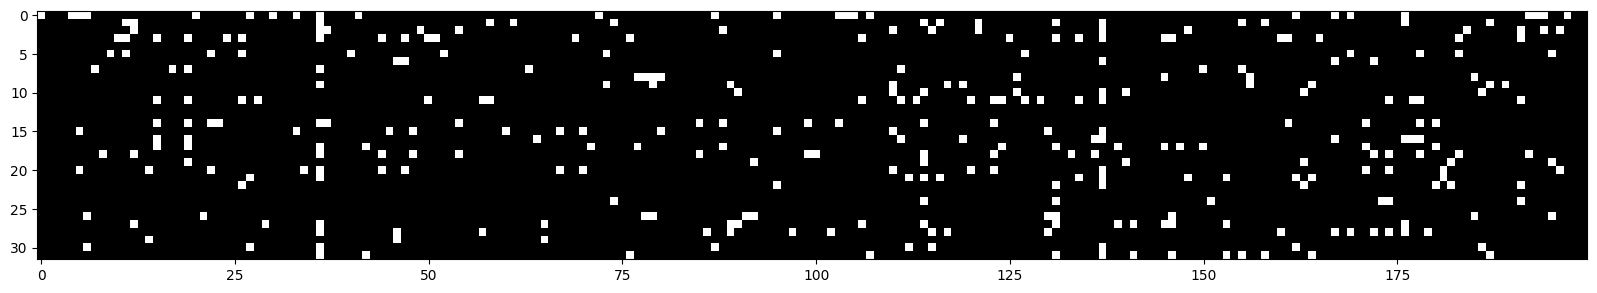

In [9]:
# tanh activations diagram, columns = hidden neurons, white column = dead neuron
# this diagram show if tanh has too many activations, if does the diagram will look like QR code
plt.figure(figsize=(20, 10))
plt.imshow(h.abs() > 0.99, cmap='gray', interpolation='nearest')

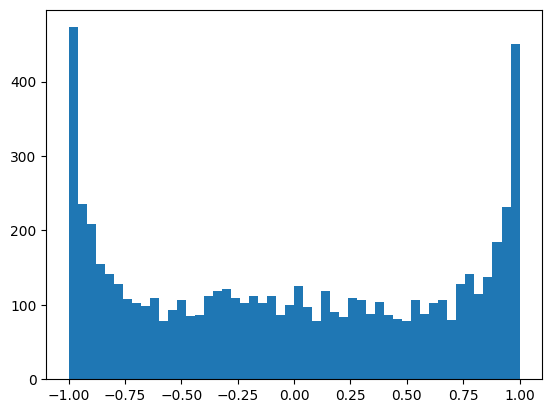

In [10]:
# hidden layer histogram
plt.hist(h.view(-1).tolist(), 50);

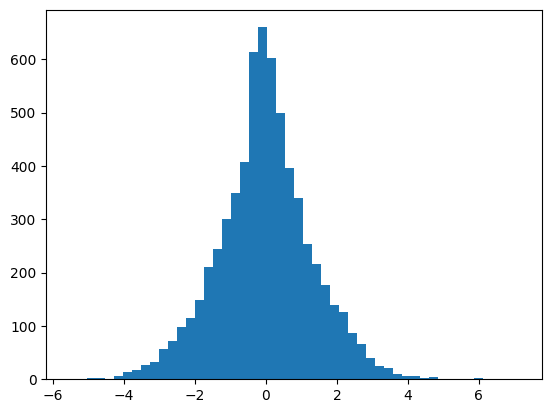

In [11]:
# hidden layer pre-actiovation histogram
plt.hist(h_preact.view(-1).tolist(), 50);

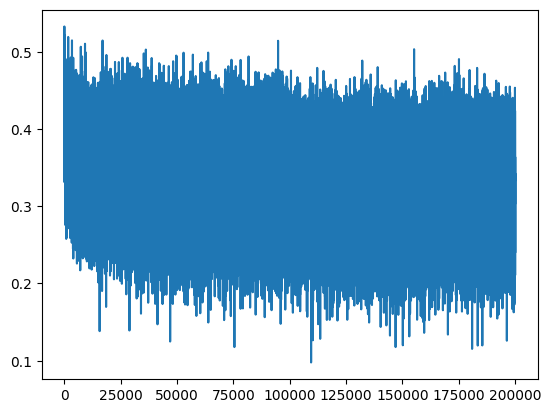

In [12]:
plt.plot(loss_i)

In [13]:
@torch.no_grad() # this decorator disables gradient tracking
def split_loss(split):
    x, y = {
        'train': (X_tr, Y_tr),
        'val': (X_dev, Y_dev),
        'test': (X_te, Y_te)
    }[split]
    emb = C[x] # (N, block_size, n_embed)
    emb_cat = emb.view(emb.shape[0], -1) # concat into (N, block_size * n_embed)
    h_preact = emb_cat @ W1 #+ b1
    h_preact = bn_gain * (h_preact - bn_mean_running) / bn_std_running + bn_bias # batch normalization
    h = torch.tanh(h_preact) # (N, n_hidden)
    logits = h @ W2 + b2 # (N, vocab_size)
    loss = F.cross_entropy(logits, y)
    print(split, loss.item())

split_loss('train')
split_loss('val')

train 2.0674145221710205
val 2.1056838035583496


In [14]:
# sample from the model
g = torch.Generator().manual_seed(2147483647 + 10)

for _ in range(20):

    out = []
    context = [0] * block_size # initialize with all ...
    while True:
        # forward pass the neural net
        emb = C[torch.tensor([context])] # (1, block_size, n_embd)
        h = torch.tanh(emb.view(1, -1) @ W1)
        logits = h @ W2 + b2
        probs = F.softmax(logits, dim=1)

        # sample from the distribution
        ix = torch.multinomial(probs, num_samples=1, generator=g).item()

        # shift the context window and track samples
        context = context[1:] + [ix]
        out.append(ix)

        # if we sample the special '.' character, break
        if ix == 0:
            break
    
    print(''.join(itos[i] for i in out)) # decode and print the generated words

cathlifatubhl.
shkirrsthlitslestadsh.
jazhmirfardsahmiqueliz.
qumaritzieiirdg.
leggyufbmghziriqustzishlistan.
vabiusstell.
diarisix.
khegzifsabbel.
zaiirsgyasluysfaadhlanyivariksyah.
maboubzettr.
jesiahasdannakphladlummygotberksiaghubniq.
qlylianaysh.
xeinahqueld.
bldn.
tdy.
madthgb.
sphlynanyasislytte.
conzabbuljadak.
khlesdanikosmuseff.
kyaq.


In [29]:
# Torchify the code - train a deeper network

class Linear:

    def __init__(self, fan_in, fan_out, bias=True):
        self.weight = torch.randn((fan_in, fan_out), generator=g) / fan_in ** 0.5
        self.bias = torch.zeros(fan_out) if bias else None

    def __call__(self, x):
        self.out = x @ self.weight
        if self.bias is not None:
            self.out += self.bias
        return self.out

    def parameters(self):
        return [self.weight] + ([] if self.bias is None else [self.bias])


class BatchNorm1d:

    def __init__(self, dim, eps=1e-5, momentum=0.1):
        self.eps = eps
        self.momentum = momentum
        self.training = True
        # parameters (trained with backpropagation)
        self.gamma = torch.ones(dim)
        self.beta = torch.zeros(dim)
        # buffers (trained with a running 'momentum update')
        self.running_mean = torch.zeros(dim)
        self.running_var = torch.ones(dim)

    def __call__(self, x):
        # calculate the forward pass
        if self.training:
            x_mean = x.mean(0, keepdim=True) # batch mean
            x_var = x.var(0, keepdim=True) # batch variance
        else:
            x_mean = self.running_mean
            x_var = self.running_var
        x_hat = (x - x_mean) / torch.sqrt(x_var + self.eps) # normalize to unit variance
        self.out = self.gamma * x_hat + self.beta
        # update the buffers
        if self.training:
            with torch.no_grad():
                self.running_mean = (1 - self.momentum) * self.running_mean + self.momentum * x_mean
                self.running_var = (1 - self.momentum) * self.running_var + self.momentum * x_var
        return self.out

    def parameters(self):
        return [self.gamma, self.beta]


class Tanh:

    def __call__(self, x):
        self.out = torch.tanh(x)
        return self.out

    def parameters(self):
        return []

n_embd = 10 # the dimensionality of the character embedding vectors
n_hidden = 100 # the number of neurons in the hidden layer of the MLP
g = torch.Generator().manual_seed(2147483647) # used for reproducibility

C = torch.randn((vocab_size, n_embd), generator=g)

layers = [
    Linear(n_embd * block_size, n_hidden), BatchNorm1d(n_hidden), Tanh(),
    Linear(           n_hidden, n_hidden), BatchNorm1d(n_hidden),Tanh(),
    Linear(           n_hidden, n_hidden), BatchNorm1d(n_hidden),Tanh(),
    Linear(           n_hidden, n_hidden), BatchNorm1d(n_hidden),Tanh(),
    Linear(           n_hidden, n_hidden), BatchNorm1d(n_hidden),Tanh(),
    Linear(           n_hidden, vocab_size), BatchNorm1d(vocab_size),
]

with torch.no_grad():
    # last layer: make less confident
    layers[-1].gamma *= 0.1 # when using the BatchNorm1d layers otherwise: layers[-1].weight *= 0.1
    # all other layers: apply gain
    for layer in layers[:-1]:
        if isinstance(layer, Linear):
            layer.weight *= 5/3

parameters = [C] + [p for layer in layers for p in layer.parameters()]
print(sum(p.nelement() for p in parameters)) # print number of parameters in total
for p in parameters:
    p.requires_grad = True

47551


In [30]:
# optimization
max_steps = 200000
batch_size = 32
loss_i = []
update_to_data = []

for i in range(max_steps):

    # minibatch construct
    ix = torch.randint(0, X_tr.shape[0], (batch_size,), generator=g)
    X_batch, Y_batch = X_tr[ix], Y_tr[ix] # batch X, Y

    # forwards pass
    emb = C[X_batch] # embed the characters into vectors
    x = emb.view(emb.shape[0], -1) # concatenate the vectors

    for layer in layers:
        x = layer(x)
    loss = F.cross_entropy(x, Y_batch) # loss function

    # backward pass
    for layer in layers:
        layer.out.retain_grad()

    for p in parameters:
        p.grad = None
    loss.backward()
    
    # update
    lr = 0.1 if i < 100000 else 0.01 # step learning rate decay
    for p in parameters:
        p.data += -lr * p.grad

    # track stats
    if i % 10000 == 0: # print every once in a while
        print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
    loss_i.append(loss.log10().item())

    with torch.no_grad():
        update_to_data.append([(lr * p.grad.std() / p.data.std()).log10().item() for p in parameters])

    if i >= 1000:
        break

      0/ 200000: 3.2870


layer 2 (      Tanh): mean -0.00, std 0.63, saturated: 2.62%
layer 5 (      Tanh): mean +0.00, std 0.64, saturated: 2.47%
layer 8 (      Tanh): mean -0.00, std 0.64, saturated: 2.16%
layer 11 (      Tanh): mean +0.00, std 0.65, saturated: 1.81%
layer 14 (      Tanh): mean -0.00, std 0.65, saturated: 1.78%


Text(0.5, 1.0, 'Activation distribution')

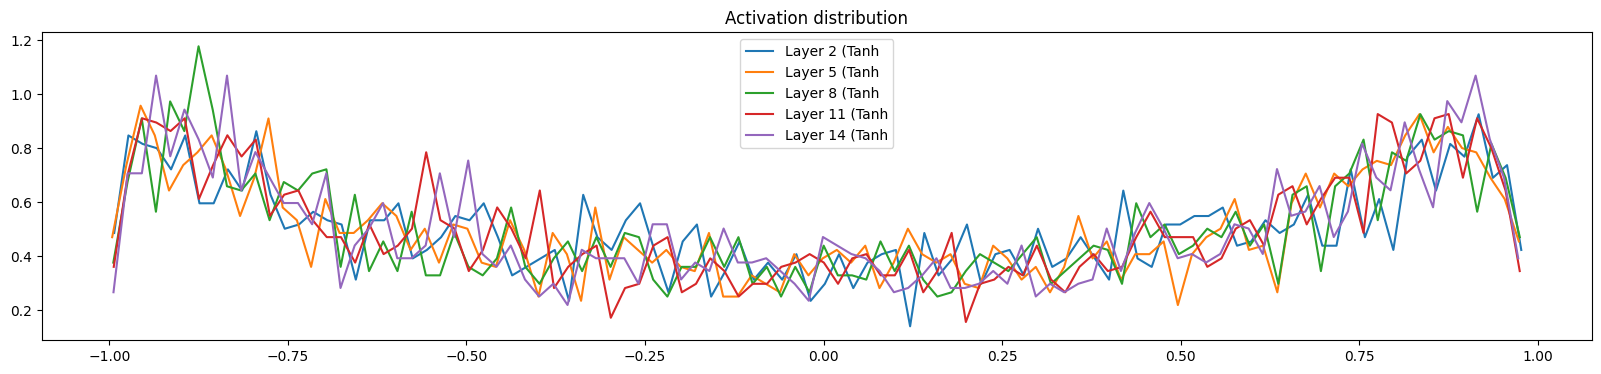

In [31]:
# activation distribution plot
plt.figure(figsize=(20, 4)) # width and height of the plot
legends = []

for i, layer in enumerate(layers[:-1]): # note: exclude the output layer
    if isinstance(layer, Tanh):
        t = layer.out
        print('layer %d (%10s): mean %+.2f, std %.2f, saturated: %.2f%%' % (i, layer.__class__.__name__, t.mean(), t.std(), (t.abs() > 0.97).float().mean() * 100))
        hy, hx = torch.histogram(t, density=True)
        plt.plot(hx[:-1].detach(), hy.detach())
        legends.append(f'Layer {i} ({layer.__class__.__name__}')
plt.legend(legends);
plt.title('Activation distribution')

layer 2 (      Tanh): mean +0.000000, std 3.682950e-03, saturated: 0.00%
layer 5 (      Tanh): mean -0.000000, std 3.262607e-03, saturated: 0.00%
layer 8 (      Tanh): mean -0.000000, std 2.973728e-03, saturated: 0.00%
layer 11 (      Tanh): mean +0.000000, std 2.741108e-03, saturated: 0.00%
layer 14 (      Tanh): mean +0.000000, std 2.584293e-03, saturated: 0.00%


Text(0.5, 1.0, 'Gradient distribution')

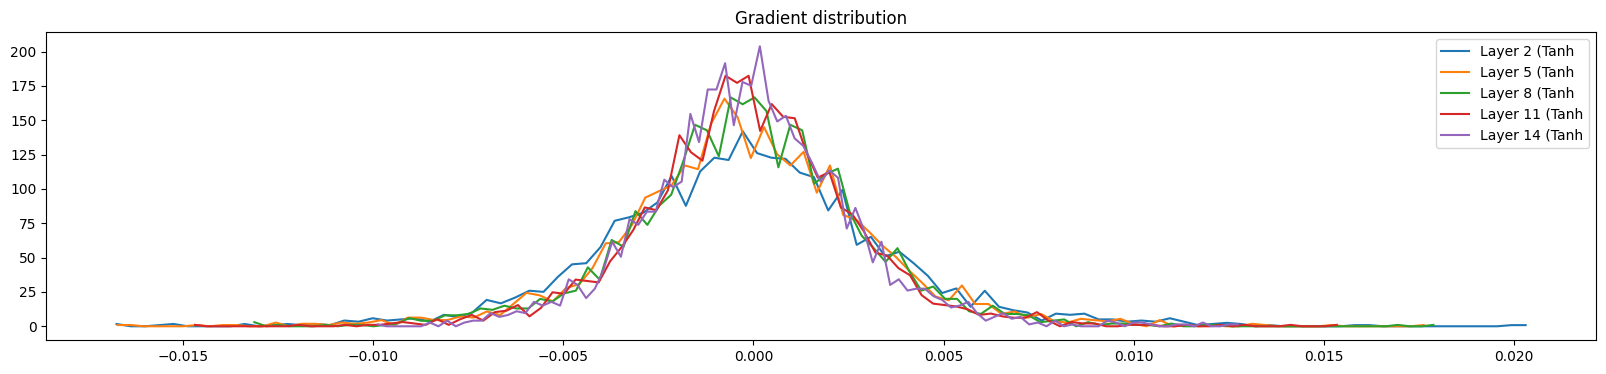

In [32]:
# gradient distribution plot
plt.figure(figsize=(20, 4)) # width and height of the plot
legends = []

for i, layer in enumerate(layers[:-1]): # note: exclude the output layer
    if isinstance(layer, Tanh):
        t = layer.out.grad
        print('layer %d (%10s): mean %+f, std %e, saturated: %.2f%%' % (i, layer.__class__.__name__, t.mean(), t.std(), (t.abs() > 0.97).float().mean() * 100))
        hy, hx = torch.histogram(t, density=True)
        plt.plot(hx[:-1].detach(), hy.detach())
        legends.append(f'Layer {i} ({layer.__class__.__name__}')
plt.legend(legends);
plt.title('Gradient distribution')

weight   (27, 10) | mean -0.000000 | std 1.019883e-02 | grad:data ration 1.018844e-02
weight  (30, 100) | mean +0.000092 | std 8.238423e-03 | grad:data ration 2.635837e-02
weight (100, 100) | mean +0.000031 | std 7.318103e-03 | grad:data ration 4.377139e-02
weight (100, 100) | mean -0.000019 | std 6.662023e-03 | grad:data ration 3.949895e-02
weight (100, 100) | mean -0.000019 | std 5.821514e-03 | grad:data ration 3.468160e-02
weight (100, 100) | mean +0.000053 | std 5.445293e-03 | grad:data ration 3.243365e-02
weight  (100, 27) | mean -0.000165 | std 1.046844e-02 | grad:data ration 6.281258e-02


Text(0.5, 1.0, 'Weights gradient distribution')

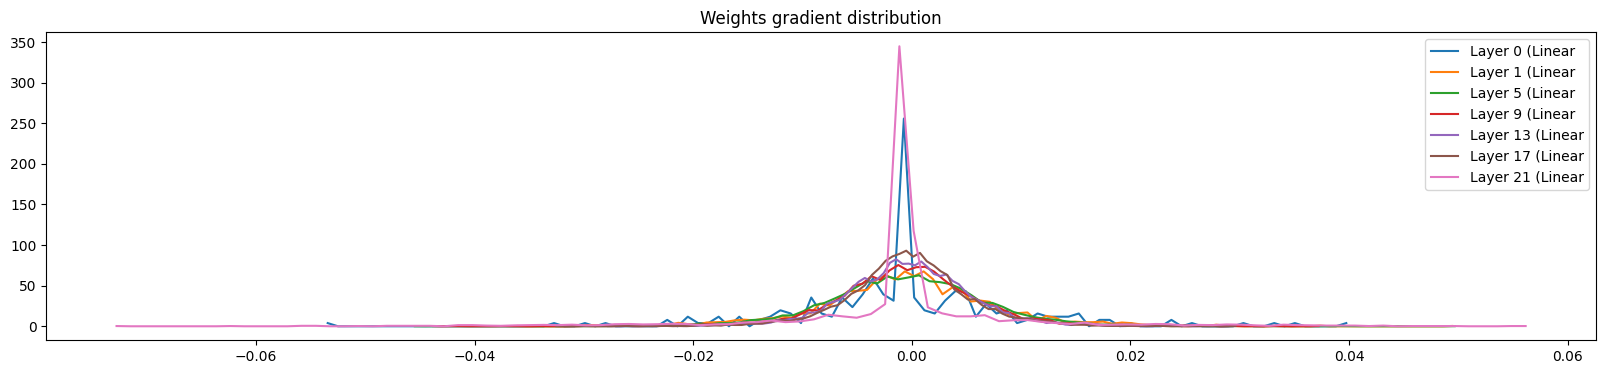

In [33]:
# weights gradient distribution plot
plt.figure(figsize=(20, 4)) # width and height of the plot
legends = []

for i, p in enumerate(parameters):
    t = p.grad
    if p.ndim == 2:
        print('weight %10s | mean %+f | std %e | grad:data ration %e' % (tuple(p.shape), t.mean(), t.std(), t.std() / p.std()))
        hy, hx = torch.histogram(t, density=True)
        plt.plot(hx[:-1].detach(), hy.detach())
        legends.append(f'Layer {i} ({layer.__class__.__name__}')
plt.legend(legends);
plt.title('Weights gradient distribution')

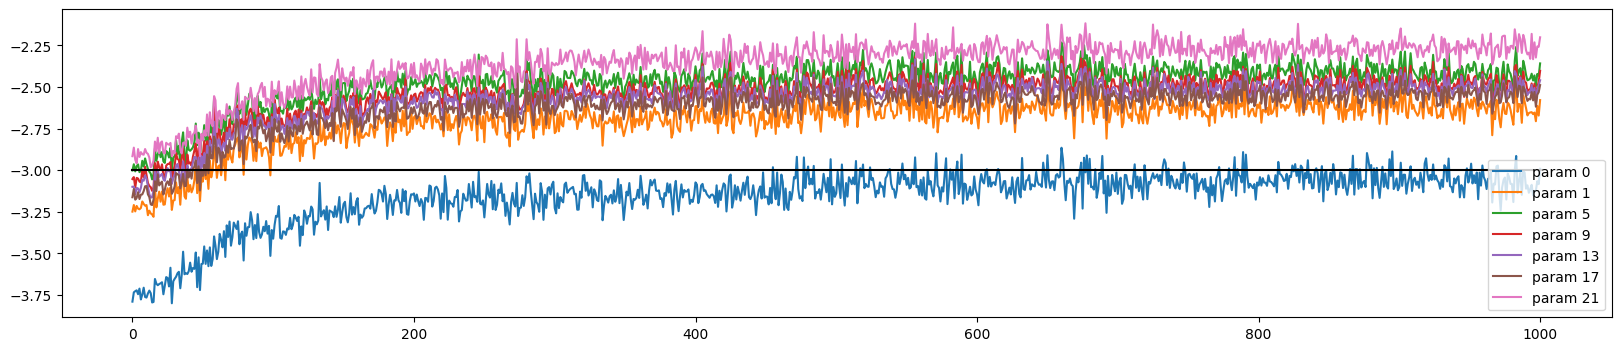

In [ ]:
# parameters updates plot
plt.figure(figsize=(20, 4))
legends = []

for i, p in enumerate (parameters):
    if p.ndim == 2:
        plt.plot([update_to_data[j][i] for j in range(len(update_to_data))])
        legends.append('param %d' % i)
plt.plot([0, len(update_to_data)], [-3, -3], 'k')
plt.legend(legends);